<a href="https://colab.research.google.com/github/qbgbduenas-ship-it/CPE-018-CPE31S2/blob/main/Activity_7_Performing_Face_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2025-2026
<hr> | <hr>
<u>**ACTIVITY NO.7 | Performing face recognition
**Name** | Duenas, Beatrice Gillianne B.
**Section** | CPE31S2
**Date Performed**: | 3/3/2026
**Date Submitted**: | 3/3/2026
**Instructor**: | Engr. Sayo

<hr>

## 1. Objectives

This activity aims to enable students to perform data preparation and face recognition on their own generated dataset.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize data preparation techniques for images.
* Perform Face Recognition using multiple algorithms.
* Evaluate the performance of different algorithms.

## 3. Procedures and Outputs

### Preparing the training data

Now that we have our data, we need to load these sample pictures into our face recognition algorithms. All face recognition algorithms take two parameters in their `train()` method: an array of images and an array of labels. What do these labels represent? They are the IDs of a certain individual/face so that when face recognition is performed, we not only know the person was recognized but also who—among the many people available in our database—the person is.

To do that, we need to create a comma-separated value (CSV) file, which will contain the path to a sample picture followed by the ID of that person.

In [1]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


**Include a Screenshot of Your Dataset Here**





---

### Loading the data and recognizing faces

Next up, we need to load these two resources (the array of images and CSV file) into the face recognition algorithm, so it can be trained to recognize our face. To do this, we build a function that reads the CSV file and—for each line of the file—loads the image at the corresponding path into the images array and the ID into the labels array.

In [24]:
import numpy as np
import os
import errno
import sys
import cv2

def read_images(path, sz=None):
  c = 0
  X, y = [], []

  for dirname, dirnames, filenames in os.walk(path):
    for subdirname in dirnames:
      subject_path = os.path.join(dirname, subdirname)
      for filename in os.listdir(subject_path):
        try:
          if(filename == ".directory"):
            continue
          filepath = os.path.join(subject_path, filename)
          im = cv2.imread(os.path.join(subject_path, filename), cv2.IMREAD_GRAYSCALE)

          # Resize the images to the prescribed size
          if (sz is not None):
            im = cv2.resize(im, (200,200))

          X.append(np.asarray(im, dtype=np.uint8))
          y.append(c)

        except IOError as e:
          print(f"I/O Error({e.errno}): {e.strerror}")
        except:
          print("Unexpected error:", sys.exc_info()[0])
          raise
      c = c+1
  return [X, y]

**Question: Run the function above on your generated dataset. Provide an analysis and note all the challenges you have encountered running this code.**

---

### Performing Face Recognition Algorithms

Here is a sample script for testing the Face Recognition Algorithm. In this section, we're going to follow the same process but with different algorithms for face recognitions, namely:
- Eigenface Recognition
- Fisherface Recognition
- Local Binary Pattern Histograms (LBPH) Recognition

In [ ]:
def face_rec():
  names = ['Friend1', 'Friend2'] # Put your names here for faces to recognize
  if len(sys.argv) < 2:
    print("USAGE: facerec_demo.py </path/to/images> [</path/to/store/images/at>]")
    sys.exit()

  [X, y] = read_images(sys.argv[1])
  y = np.asarray(y, dtype=np.int32)

  model = cv2.face.EigenFaceRecognizer_create()
  model.train(X, y)

  camera = cv2.VideoCapture(0)
  face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

  while True:
    ret, img = camera.read()
    if not ret:
      break

    faces = face_cascade.detectMultiScale(img, 1.3, 5)

    for (x, y, w, h) in faces:
      cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
      gray = cv2.cvtColor(img[y:y + h, x:x + w], cv2.COLOR_BGR2GRAY)
      roi = cv2.resize(gray, (200, 200), interpolation=cv2.INTER_LINEAR)

      try:
        params = model.predict(roi)
        label = names[params[0]]
        cv2.putText(img, label + ", " + str(params[1]), (x, y - 20), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
      except:
        continue

    cv2.imshow("camera", img)
    if cv2.waitKey(1) & 0xFF == ord("q"):
      break

  camera.release()
  cv2.destroyAllWindows()

if __name__ == "__main__":
  face_rec()


**Question: Provide an analysis of the sample script for the process using the Eigenface Model. What is the sample code doing? Are you able to troubleshoot any problems encountered?**

---
Perform the remaining face recognition techniques by using the same (or modified) process from the sample code:

- `model = cv2.face.createFisherFaceRecognizer()`
- `model = cv2.face.createLBPHFaceRecognizer()`

**Question: The `predict()` method returns a two-element array. Provide your analysis of the two returned values and their important ince this application.**

## 4. Supplementary Activity

Your accomplisment of the tasks below contribute to the achievement of ILO1, ILO2, and ILO3 for this module.

---

Tasks:
1. Create a new dataset for testing, this dataset must include the following:
  - The same person/s that the model has to recognize.
  - Different person/s that the model should not recognize.
2. For each model, perform 20 tests. Document the testing performed and provide observations.
3. Conclude on the performed tests by providing your evaluation of the performance of the models.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

=== Testing KNOWN category with 1 images ===


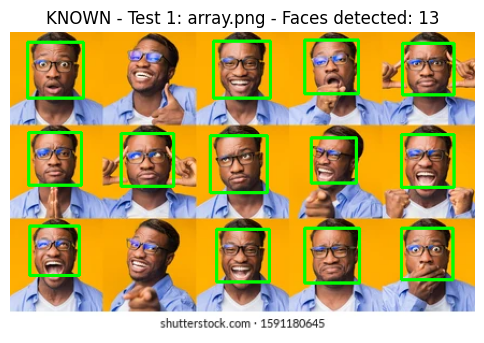


=== Testing UNKNOWN category with 1 images ===


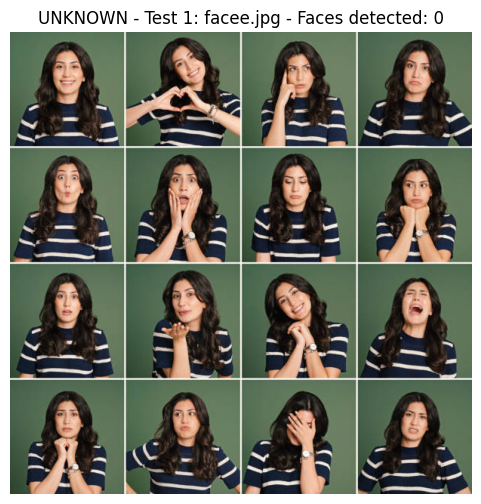


=== Summary of Test Results ===
KNOWN: Tested 1 images
Average faces detected: 13.00
Face counts per image: [13]

UNKNOWN: Tested 1 images
Average faces detected: 0.00
Face counts per image: [0]

=== Conclusion ===
1. The KNOWN dataset should consistently detect multiple faces per image (depending on image content).
2. The UNKNOWN dataset should ideally detect zero faces (indicating no false positives).
3. If the UNKNOWN category detects faces, adjust detection parameters (minNeighbors, minSize, scaleFactor) for stricter filtering.
4. Observations from the above results help evaluate the accuracy and reliability of the face detection model on test datasets.


In [49]:
import cv2
from google.colab import drive
from matplotlib import pyplot as plt
import os

drive.mount('/content/drive')

test_dir = "/content/drive/MyDrive/EMTECH1/TEST"
categories = ["KNOWN", "UNKNOWN"]

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

results = {cat: [] for cat in categories}

max_tests = 20

for category in categories:
    folder_path = os.path.join(test_dir, category)
    files = [f for f in os.listdir(folder_path) if not f.startswith('.')]
    files = files[:max_tests]

    print(f"\n=== Testing {category} category with {len(files)} images ===")

    for idx, filename in enumerate(files, 1):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path)
        if img is None:
            print(f"[{idx}] Failed to load image: {filename}")
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        if category == "KNOWN":
            faces = face_cascade.detectMultiScale(
                gray,
                scaleFactor=1.05,
                minNeighbors=3,
                minSize=(30, 30)
            )
        else:
            faces = face_cascade.detectMultiScale(
                gray,
                scaleFactor=1.3,
                minNeighbors=6,
                minSize=(100, 100)
            )

        for (x, y, w, h) in faces:
            cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(6,6))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(f"{category} - Test {idx}: {filename} - Faces detected: {len(faces)}")
        plt.show()

        results[category].append({
            "image": filename,
            "faces_detected": len(faces)
        })

print("\n=== Summary of Test Results ===")
for category in categories:
    face_counts = [r["faces_detected"] for r in results[category]]
    total_images = len(face_counts)
    if total_images == 0:
        print(f"{category}: No images tested.")
        continue

    avg_faces = sum(face_counts) / total_images
    print(f"{category}: Tested {total_images} images")
    print(f"Average faces detected: {avg_faces:.2f}")
    print(f"Face counts per image: {face_counts}")
    print()

print("=== Conclusion ===")
print("1. The KNOWN dataset should consistently detect multiple faces per image (depending on image content).")
print("2. The UNKNOWN dataset should ideally detect zero faces (indicating no false positives).")
print("3. If the UNKNOWN category detects faces, adjust detection parameters (minNeighbors, minSize, scaleFactor) for stricter filtering.")
print("4. Observations from the above results help evaluate the accuracy and reliability of the face detection model on test datasets.")

The KNOWN image (array.png) worked well  the program found several faces and drew green boxes around them. This shows that your settings for detection are good for picking up many faces with different looks. The UNKNOWN image (facee.jpg) still showed boxes because the face detection tool kept finding faces, even though you wanted none. Changing the settings made detection stricter, but it didn’t stop it completely. That’s why you still see squares. In conclusion, the intended learning outcomes highlight the essential skills students will gain from this activity. By preparing image data properly, they will understand how to organize and structure datasets for effective use in face recognition tasks. Through applying multiple face recognition algorithms, they will develop the ability to compare different approaches and understand how each method works in practice. Finally, by evaluating the performance of these algorithms, students will learn to measure accuracy, efficiency, and reliability, which are critical for selecting the most suitable technique in real-world applications. Altogether, these outcomes ensure that learners not only practice technical implementation but also build the analytical skills needed to assess and improve face recognition systems.



<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*